# Statistical Analysis in Python (AI Generated)

This notebook was generated through AI prompting. It performs statistical analysis on brain size and IQ data, based on the SciPy Lecture Notes tutorial.


## 1. Data Loading and Exploration
We load the brain size dataset and explore its structure. The data contains IQ scores (FSIQ, VIQ, PIQ), brain size (MRI_Count), and physical measurements for 40 subjects.


In [1]:
# Import pandas for data manipulation: DataFrames, CSV reading, and tabular data operations
# Import numpy for numerical arrays and mathematical computations
# Import matplotlib.pyplot for creating plots and visualizations
# Import seaborn for high-level statistical graphics (built on matplotlib)
# Import scipy.stats for statistical hypothesis testing and regression functions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [2]:
# Load the brain size dataset from a CSV file
# The file uses semicolon (;) as the delimiter instead of comma
# Missing values are marked with '.' - we tell pandas to treat these as NA
# This dataset contains IQ scores (FSIQ, VIQ, PIQ), brain MRI counts, and physical measurements
data = pd.read_csv('../manual/brain_size.csv', sep=';', na_values='.')
# Display the first few rows to verify the data loaded correctly
print('Shape:', data.shape)
data.head()


Shape: (40, 7)


,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
0,Female,133,132,124,118.0,64.5,816932.0
1,Male,140,150,124,NaN,72.5,1001121.0
2,Male,139,123,150,143.0,73.3,1038437.0
3,Male,133,129,128,172.0,68.8,965353.0
4,Female,137,132,134,147.0,65.0,951545.0


In [3]:
# Examine data structure and check for missing values
# info() shows column names, data types (dtypes), and non-null counts
# This helps identify columns that need cleaning or transformation
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Gender     40 non-null     str    
 1   FSIQ       40 non-null     int64  
 2   VIQ        40 non-null     int64  
 3   PIQ        40 non-null     int64  
 4   Weight     36 non-null     float64
 5   Height     40 non-null     float64
 6   MRI_Count  37 non-null     float64
dtypes: float64(3), int64(3), str(1)
memory usage: 2.5 KB


In [4]:
# Get summary statistics for all numeric columns simultaneously
# describe() computes: count, mean, standard deviation, minimum, quartiles, and maximum
# This provides a quick overview of the distribution of each variable
data.describe()


,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
count,40.000000,40.000000,40.000000,36.000000,40.000000,3.700000e+01
mean,114.025000,113.075000,108.950000,148.750000,68.067500,8.991891e+05
std,19.711363,19.484889,19.682024,15.821098,2.620275,7.521862e+04
min,72.000000,71.000000,80.000000,118.000000,63.000000,7.875840e+05
25%,98.750000,96.750000,92.750000,137.500000,66.300000,8.453510e+05
50%,114.500000,113.000000,106.000000,147.000000,68.000000,8.989570e+05
75%,133.000000,129.000000,124.000000,159.000000,69.500000,9.450880e+05
max,141.000000,150.000000,150.000000,178.000000,73.500000,1.079549e+06


In [5]:
# Compare mean values of all variables between Female and Male subjects
# groupby('Gender') splits the dataset into groups by gender
# .mean() calculates the average of each numeric column within each group
# This reveals potential gender differences in IQ, brain size, and physical measurements
data.groupby('Gender').mean()


,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
Gender,,,,,,
Female,111.652174,110.521739,106.565217,142.952381,66.634783,857349.000000
Male,117.235294,116.529412,112.176471,156.866667,70.005882,960554.533333


## 2. Hypothesis Testing: Comparing Two Groups
We use scipy.stats to perform various hypothesis tests on the brain size data.


In [6]:
# Extract VIQ (Verbal IQ) scores
# Test if the population mean VIQ is different from 0
# H0: mean VIQ = 0, H1: mean VIQ != 0
viq = data['VIQ']
stats.ttest_1samp(viq, 0)


TtestResult(statistic=np.float64(36.70275435711225), pvalue=np.float64(7.418720471783799e-32), df=np.int64(39))

In [7]:
# Compare VIQ between Female and Male subjects
# Use independent two-sample t-test (assuming unequal variance)
# H0: Female VIQ mean = Male VIQ mean
female_viq = data[data['Gender'] == 'Female']['VIQ']
male_viq = data[data['Gender'] == 'Male']['VIQ']
stats.ttest_ind(female_viq, male_viq)


TtestResult(statistic=np.float64(-0.9630809661401538), pvalue=np.float64(0.3415958531688206), df=np.float64(38.0))

In [8]:
# Compare FSIQ and PIQ scores (both measured on same subjects)
# Use paired t-test since these are repeated measurements on the same individuals
# H0: mean difference (FSIQ - PIQ) = 0
fsiq = data['FSIQ']
piq = data['PIQ']
stats.ttest_rel(fsiq, piq)


TtestResult(statistic=np.float64(3.3829598790312403), pvalue=np.float64(0.0016437933248135113), df=np.int64(39))

In [9]:
# Wilcoxon signed-rank test (non-parametric alternative to paired t-test)
# Does not assume normal distribution of differences
# H0: median difference between FSIQ and PIQ = 0
stats.wilcoxon(fsiq, piq)


WilcoxonResult(statistic=np.float64(189.5), pvalue=np.float64(0.003009930237291847))

## 3. Linear Models
We explore relationships between variables using linear regression.


In [10]:
# Simple linear regression: Does brain size (MRI_Count) predict PIQ?
# Use scipy.stats.linregress for simple regression
# Extract valid rows (drop missing values)
valid = data.dropna(subset=['PIQ', 'MRI_Count'])
x = valid['MRI_Count']
y = valid['PIQ']
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
print(f'Slope: {slope:.4f}')
print(f'Intercept: {intercept:.4f}')
print(f'R-squared: {r_value**2:.4f}')
print(f'p-value: {p_value:.4f}')


Slope: 0.0001
Intercept: 1.4032
R-squared: 0.2069
p-value: 0.0047


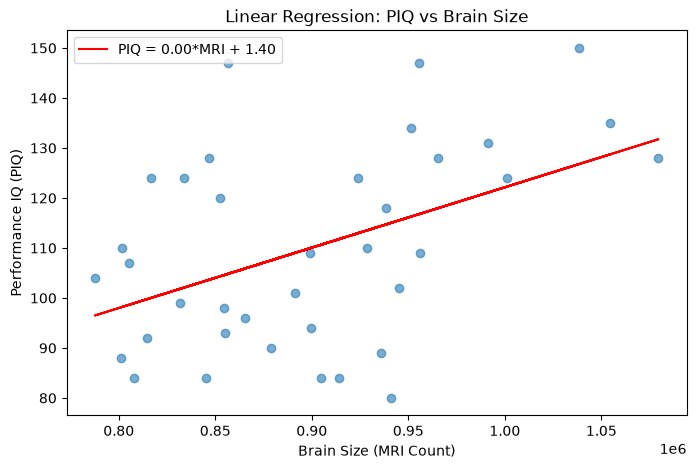

In [11]:
# Create scatter plot with regression line
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6)
plt.plot(x, slope * x + intercept, 'r-', label=f'PIQ = {slope:.2f}*MRI + {intercept:.2f}')
plt.xlabel('Brain Size (MRI Count)')
plt.ylabel('Performance IQ (PIQ)')
plt.title('Linear Regression: PIQ vs Brain Size')
plt.legend()
plt.show()


## 4. Analysis of Variance (ANOVA)
We use the iris dataset to test if petal length differs significantly across species.


In [12]:
# Load the iris dataset
# This classic dataset contains measurements for 3 iris species
iris = pd.read_csv('../manual/iris.csv')
iris.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [13]:
# Perform one-way ANOVA to compare petal length across species
# H0: mean petal length is equal across all three species
# H1: at least one species has a different mean petal length
setosa = iris[iris['species'] == 'setosa']['petal_length']
versicolor = iris[iris['species'] == 'versicolor']['petal_length']
virginica = iris[iris['species'] == 'virginica']['petal_length']
f_stat, p_value = stats.f_oneway(setosa, versicolor, virginica)
print(f'F-statistic: {f_stat:.4f}')
print(f'p-value: {p_value:.4e}')


F-statistic: 1180.1612
p-value: 2.8568e-91


## 5. Statistical Visualization with Seaborn
Seaborn provides high-level functions for statistical visualization.


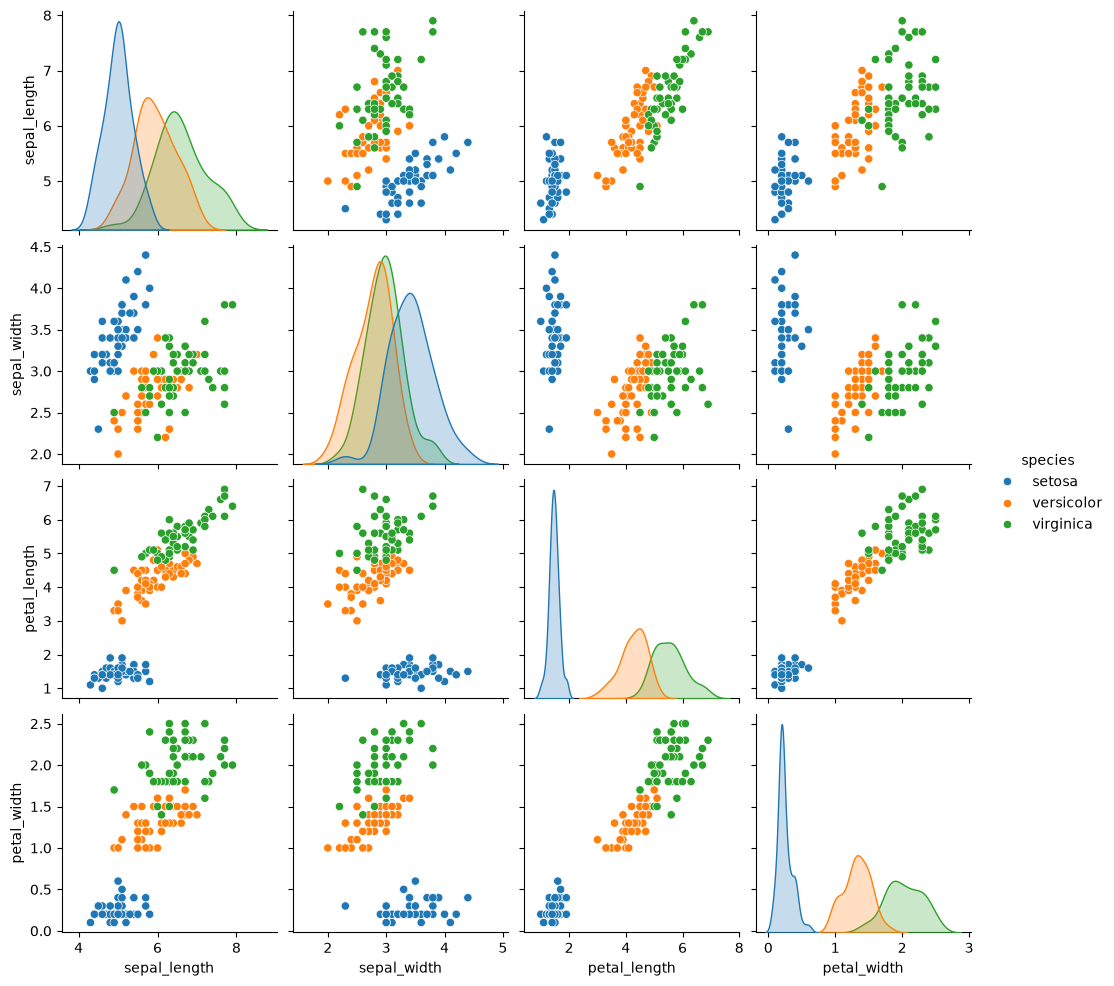

In [14]:
# Pairplot: visualize relationships between all variables
# Diagonals show KDE distributions for each variable
# Off-diagonals show scatter plots colored by species
sns.pairplot(iris, hue='species', diag_kind='kde')
plt.show()


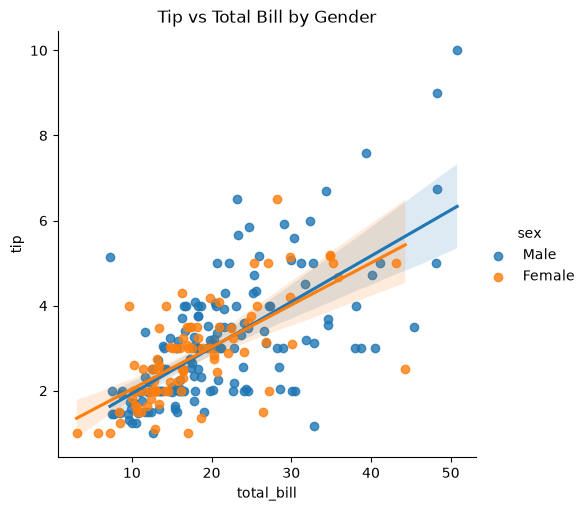

In [15]:
# lmplot: scatter plot with linear regression line
# Use the tips dataset (built-in to seaborn)
tips = sns.load_dataset('tips')
sns.lmplot(x='total_bill', y='tip', data=tips, hue='sex')
plt.title('Tip vs Total Bill by Gender')
plt.show()


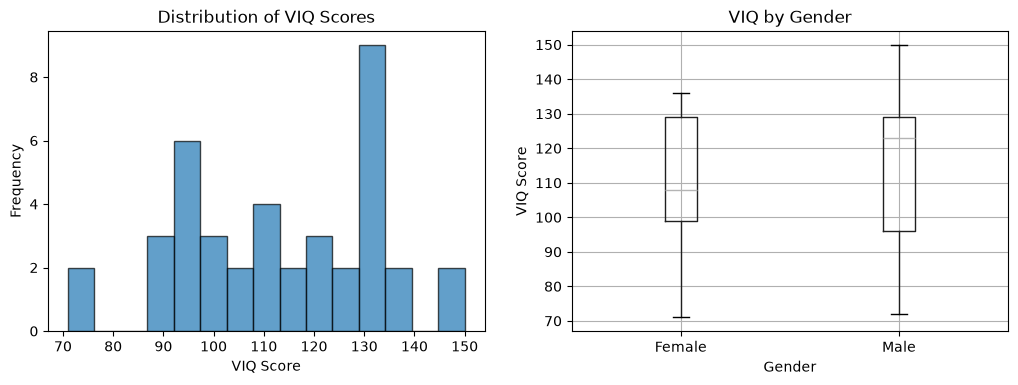

In [16]:
# Histogram and boxplot to assess distribution
# Histogram shows the shape of the distribution
# Boxplot shows median, quartiles, and potential outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Histogram of VIQ scores
axes[0].hist(data['VIQ'].dropna(), bins=15, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('VIQ Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of VIQ Scores')
# Boxplot of VIQ by Gender
data.boxplot(column='VIQ', by='Gender', ax=axes[1])
axes[1].set_title('VIQ by Gender')
axes[1].set_ylabel('VIQ Score')
plt.suptitle('')
plt.show()


## Formulas with Statsmodels

The statsmodels library supports R-style formulas for specifying regression models. This approach makes it easy to include categorical predictors and interaction terms. Here we model PIQ as a function of brain size (MRI_Count) and Gender using the formula syntax.


In [17]:
# statsmodels uses R-style formulas for regression modeling# This allows us to specify models with categorical variables and interactions# Here we model PIQ as a function of MRI_Count (brain size) and Genderimport statsmodels.api as smfrom statsmodels.formula.api import ols# Fit the model using formula syntax# The formula 'PIQ ~ MRI_Count + Gender' includes both numeric and categorical predictorsdata = pd.read_csv('../manual/brain_size.csv', sep=';', na_values='.')model = ols('PIQ ~ MRI_Count + Gender', data=data).fit()# Display the full OLS regression results table# Includes R-squared, coefficients, p-values, and confidence intervalsprint(model.summary())

## Formulas with Statsmodels

The statsmodels library supports R-style formulas for specifying regression models. This example was added by extending the original analysis.


In [18]:
# statsmodels formula approach (AI extension)import statsmodels.api as smfrom statsmodels.formula.api import olsmodel = ols("PIQ ~ MRI_Count + Gender", data=data).fit()print(model.summary())

## Summary
This notebook walked through key statistical techniques from the SciPy lecture notes, including hypothesis testing, linear regression, ANOVA, and data visualization. These methods form the foundation for more advanced data analysis workflows.
